# Extrapolasi

Ekstrapolasi berbeda dengan interpolasi, karena dalam ekstrapolasi fungsi yang didapat tidak harus melelui titik-titik data yang diberikan. Tujuan penggunaan metode ekstrapolasi adalah untuk menemukan fungsi yang mengikuti tren dari data. Fungsi yang didapat bisa digunakan untuk menemukan kurva terbaik untuk interpretasi, juga untuk memperkirakan perilaku fenomena yang diamati di luar data yang dimiliki.

Aplikasi dari ekstrapolasi bukan hanya pada analisis data, namun juga digunakan pada perangkat lunak desain dan optimasi bentuk, seperti _Kurva Bezier_. Dalam bahasan ini digunakan ekstrapolasi menggunakan fungsi polinomial.

## Metode kuadrat terkecil (_Least Squares_)

Untuk menentukan apakah sebuah kurva yang dipilih untuk mendeskripsikan data cocok, dilakukan dengan menggunakan metode kuadrat terkecil (_Least Squares_). Perbedaan antara kurva yang dipilih dengan data yang dimiliki dihitung dengan menggunakan hubungan berikut,
$$s=\sum_{i=0}^n \left[y_i - f(x_i)\right]^2$$

Pada persamaan ini $y_i$ adalah data yang diketahui dan $f(x_i)$ adalah fungsi dari kurva yang digunakan. Dalam hal ini  $s$ adalah jumlah total dari simpangan data terhadap fungsi. Jika nilai $s$ sangat kecil, maka dapat dikatakan bahwa kurva cocok untuk mendeskripsikan data. Jika $s=0$ artinya data $y_i$ berimpit dengan kurva $f(x_i)$. Dalam persamaan diatas suku $y_i-f(x_i)$ dikenal dengan **residu** (_residual_).

Dalam pengukuran, data yang didapat selalu memiliki derau (_noise_) sehingga pada skala yang sangat teliti deviasi dari fungsi yang sesungguhnya akan selalu ada. Untuk mendapatkan parameter yang paling baik dilakukan dengan mencari konfigurasi parameter yang membuat $s$ minimum. Proses ini dikenal dengan _minimalisasi_, dan dilakukan dengan melihat perubahan nilai $s$ terhadap perubahan parameter,
$$
\frac{\partial s(a_k)}{\partial a_k} = 0; k=0, 1, ..., m
$$
dengan $a_k$ adalah parameter fungsi. Dalam persamaan diatas digunakan $m$ buah parameter, dan $s(a_k)$ bergantung pada parameter-parameter tersebut. Kurva terbaik dapat dibangun dengan superposisi dari berbagai macam fungsi. Jika fungsi dari kurva adalah polinomial, maka $m$ menunjukkan orde dari fungsi polinomial, sebagai berikut,
$$
f(x) = a_0 + a_1 x + a_2 x^2 + ... + a_m x^m
$$
Besarnya penyimpangan data dari kurva yang digunakan tergambar dari nilai simpangan baku, $\sigma$, yang dapat dihitung dengan, $$\sigma = \sqrt{\frac{s}{n-m}}$$ Perhatikan bahwa, jika $m=n$ proses yang dilakukan bukan ekstrapolasi, melainkan interpolasi yang mana data selalu berimpit dengan kurva.

## Pencocokan menggunakan garis (regresi linear)

Sebuah garis dituliskan menggunakan ekspresi matematik berikut,
$$f(x)=a_0 + a_1x$$
Dalam kasus ini fungsi yang akan diminimisasi adalah,
$$s(a_0,a_1) = \sum_{i=0}^n [y_i -f(x_i)]^2 = \sum_{i=0}^n [y_i - a_0 - a_1x_i]^2$$

Proses minimalisasi dilakukan dengan mengambil turunan dari $s$ terhadap perubahan parameter $a_0, a_1, ..., a_m$. Untuk dua parameter, $a_0$ dan $a_1$, 
$$
\begin{aligned}
\frac{\partial s}{\partial a_0} &=0 \\
\frac{\partial s}{\partial a_1} &=0
\end{aligned}
$$
didapat,
$$
\begin{aligned}
a_0 &= \frac{\bar y\sum x_i^2 - \bar x \sum x_i y_i}{\sum x_i^2-n\bar x^2} \\
a_1 &= \frac{\sum x_i y_i - \bar x \sum y_i}{\sum x_i^2 - n\bar x^2}
\end{aligned}
$$

Dalam persamaan ini $\bar x$ dan $\bar y$ adalah rata-rata.
$$
\begin{aligned}
\bar x &=\frac{1}{n+1} \sum_{i=0}^n x_i \\
\bar y &=\frac{1}{n+1} \sum_{i=0}^n y_i 
\end{aligned}
$$

Persamaan regresi dapat dituliskan pula dalam bentuk,
$$a_1=\frac{\sum y_i(x_i-\bar x)}{\sum x_i(x_i - \bar x)};~~~ a_0 = \bar y - \bar x a_1$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

         0       2.40       2.33
         1       2.62       2.39
         2       2.84       2.36
         3       3.07       3.45
         4       3.29       2.93
         6       3.51       3.80
         7       3.73       3.76
         8       3.96       4.31
         9       4.18       4.06
        10       4.40       4.62


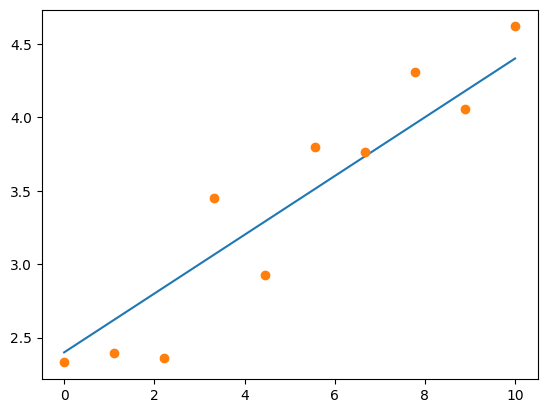

In [2]:
# membuat data

xd=np.linspace(0,10, 10)
yd=0.2*xd+2.4

yn=yd+0.5-np.random.rand(10)

for i in range(len(xd)):
    print(f'{xd[i]:10.0f} {yd[i]:10.2f} {yn[i]:10.2f}')

plt.plot(xd,yd,'-')
plt.plot(xd,yn,'o')
plt.show()

persamaan garis: y=0.24x + 2.21


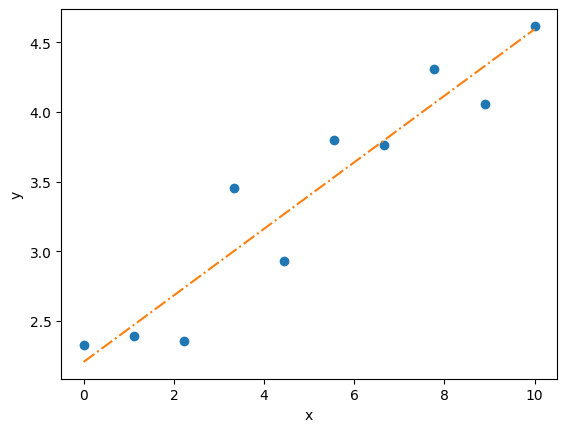

In [3]:
def bar(x):
    return sum(x)/len(x)

def reglin(x, y):
    xbar=bar(x)
    ybar=bar(y)
    a0=sum(y*(x-xbar))/sum(x*(x-xbar))
    a1=ybar-xbar*a0
    return a0,a1

a,b=reglin(xd,yn)
print(f'persamaan garis: y={a:0.2f}x + {b:0.2f}')

xe=np.linspace(xd[0],xd[-1], 100)
xf=a*xe+b;
plt.plot(xd, yn, 'o')
plt.plot(xe, xf, '-.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Pencocokan kurva dengan fungsi gabungan

Kurva yang akan digunakan untuk dicocokan pada data dapat berupa gabungan dari banyak bentuk fungsi. Dapat dituliskan,
$$
f(x) = \alpha_0f_0(x) + \alpha_1f_1(x) + ... + \alpha_mf_m(x) = \sum_{i=0}^m \alpha_if_i(x)
$$

Fungsi $f_i(x)$ disebut dengan fungsi-fungsi dasar (_basis function_), yang dapat berupa fungsi polinomial seperti,
$$\alpha_if_i(x)=\alpha_ix^i$$
yang parameter-parameternya merupakan koefisien dari fungsi polinomial. Parameter ini dapat diketahui dengan menggunakan metode pencocokan kurva. Namun perlu diperhatikan bahwa metode ini hanya baik untuk dilakukan pada nilai $m$ kecil. Pada prakteknya orde polinomial yang terlalu tinggi dapat menghasilkan osilasi yang tidak dikehendaki.

### Pencocokan polinomial

Persamaan kuadrat terkecil dengan menggunakan fungsi gabungan seperti diatas adalah,
$$
s=\sum_{i=0}^n \left[y_i - \sum_{j=0}^m \alpha_j f_j(x_i)\right]^2
$$
Untuk mendapatkan kuadrat terkecil maka turunan dari persamaan ini harus nol, $\frac{\partial s}{\partial \alpha_k}$, dengan $k$ indeks dari parameter fungsi dasar $k=0, 1, ..., m$. Sehingga dapat dilihat bahwa $m$ adalah banyaknya fungsi dasar yang membentuk kurva.

Melalui aturan turunan,
$$
\frac{\partial}{\partial x} [g(x)]^a = a[g(x)]^{a-1}\cdot \frac{\partial}{\partial x} g(x)
$$ didapat,

$$
-2\left\{\sum_{i=0}^n\left[y_i - \sum_{j=0}^m \alpha_jf_j(x_i)\right]f_k(x_i)\right\}=0
$$

Dengan menyusun ulang dapat dilihat bahwa ini merupakan sistem  persamaan linear,
$$
\sum_{j=0}^m\left[\sum_{i=0}^n f_j(x_i)f_k(x_i)\right] \alpha_j = \sum_{i=0}^n f_k(x_i)y_i
$$

dapat dituliskan sebagai persamaan linier,
$$
\begin{array}{c}
{\bf A}{\boldsymbol\alpha} = {\boldsymbol \beta} \\
\left[\begin{matrix}
a_{00} & a_{01} & ... & a_{0m} \\
a_{01} & a_{11} & ... & a_{1m} \\
\vdots &\vdots & & \vdots  \\
a_{0m} & a_{1m} & ... & a_{mm} 
\end{matrix}\right]
\left[\begin{matrix}
\alpha_0 \\ \alpha_1 \\ \vdots \\\alpha_m
\end{matrix}\right] =
\left[\begin{matrix}
\beta_0 \\ \beta_1 \\ \vdots \\ \beta_m
\end{matrix}\right]
\end{array}
$$
Perhatikan bahwa dalam matriks dan vektor disini indeks dimulai dari nol, dan koefisien-koefisien matriks bersifat simetri, yaitu $a_{kj}=a_{jk}$.

Elemen-elemen dari koefisien matriks bukan bilangan tunggal melainkan perkalian nilai-nilai fungsi,
$$
a_{kj}=\sum_{i=0}^n f_k(x_i)f_j(x_i); ~~~ \beta_k=\sum_{i=0}^0 f_k(x_i)y_i
$$

Parameter-parameter persamaan dasar $\alpha_j$ dapat diketahui dengan menggunakan metode eliminasi.

Kita ambil contoh untuk persamaan polinomial orde-3 kita dapat menuliskan,
$$
\begin{aligned}
f_0(x) &=1\\
f_1(x) &=x\\
f_2(x) &=x^2\\ 
f_3(x) &=x^3
\end{aligned}
$$
sehingga elemen-elemen matriks dan vektor konstanta dapat dicari melalui,
$$
\begin{aligned}
a_{kj} &=\sum_{i=0}^n x^k\times x^j = \sum x^{k+j} \\
b_k &=\sum_{i=0}^n x_i^k y_i 
\end{aligned}
$$

Jika dituliskan dalam persamaan matriks,

$$
\begin{array}{c}
{\bf Au} = {\bf v} \\
\left[\begin{matrix}
n & \sum x_i & \sum x_i^2 & x_i^3 \\
\sum x_i & \sum x_i^2 & \sum x_i^3 & \sum x_i^4 \\
\sum x_i^2 &\sum x_i^3 & \sum x_i^4 & \sum x_i^5  \\
\sum x_i^3 & \sum x_i^4 & \sum x_i^5 & \sum x_i^6 
\end{matrix}\right]
\left[\begin{matrix}
\alpha_0 \\ \alpha_1 \\ \alpha_2 \\\alpha_3
\end{matrix}\right] =
\left[\begin{matrix}
\sum y_i \\ \sum x_iy_i \\ \sum x_i^2y_i \\ \sum x_i^3y_i
\end{matrix}\right]
\end{array}
$$

Harus diingat bahwa semua nilai $x_i$ dan $y_i$ dalam sistem persamaan adalah data-data yang diketahui (berupa angka). Dengan demikian persamaan diatas dengan mudah dapat dibangun dan diselesaikan dengan menggunakan metode eliminasi standar.

In [4]:
# Prosedur eliminasi Gauss dengan menggunakan pivot

def swapRows(v,i,j):
    if len(v.shape) == 1:
        v[i],v[j] = v[j],v[i]
    else:
        v[[i,j],:] = v[[j,i],:]

def swapCols(v,i,j):
    v[:,[i,j]] = v[:,[j,i]]

# Gauss dengan Pivot
def gaussPivot(a,b,tol=1.0e-12):
    n = len(b)
    s = np.zeros(n)
    
    for i in range(n):
        s[i] = max(np.abs(a[i,:]))

    for k in range(0,n-1):
        p = np.argmax(np.abs(a[k:n,k])/s[k:n]) + k
    
        if abs(a[p,k]) < tol: 
            print('singular matrix')
            return 0

        if p != k:
            swapRows(b,k,p)
            swapRows(s,k,p)
            swapRows(a,k,p)

        for i in range(k+1,n):
            if a[i,k] != 0.0:
                lam = a[i,k]/a[k,k]
                a[i,k+1:n] = a[i,k+1:n] - lam*a[k,k+1:n]
                b[i] = b[i] - lam*b[k]

    if abs(a[n-1,n-1]) < tol:
        print('singular matrix')
        return 0

    b[n-1] = b[n-1]/a[n-1,n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - np.dot(a[k,k+1:n],b[k+1:n]))/a[k,k]
  
    return b

### Algoritma dan implementasi program

Berikut adalah implementasi dari prosedur pencocokan kurva polinomial
Langkah-langkahnya terdiri dari:

1. Penyusunan elemen-elemen matriks
2. Eliminasi menggunakan metode Gauss dengan pivot

In [5]:
# Hitung parameter menggunakan eliminasi
def polyFit(xData,yData,m):
    a = np.zeros((m+1,m+1))
    b = np.zeros(m+1)
    s = np.zeros(2*m+1)
    
    for i in range(len(xData)):
        temp = yData[i]
        for j in range(m+1):
            b[j] = b[j] + temp
            temp = temp*xData[i]
        temp = 1.0
        for j in range(2*m+1):
            s[j] = s[j] + temp
            temp = temp*xData[i]
        
    for i in range(m+1):
        for j in range(m+1):
            a[i,j] = s[i+j]
        
    return gaussPivot(a,b)

# Hitung simpangan baku dari pencocokan kurva
def stdDev(c,xData,yData):

    def evalPoly(c,x):
        m = len(c) - 1
        p = c[m]
        for j in range(m):
            p = p*x + c[m-j-1]
        return p

    n = len(xData) - 1
    m = len(c) - 1
    sigma = 0.0
    
    for i in range(n+1):
        p = evalPoly(c,xData[i])
        sigma = sigma + (yData[i] - p)**2

    sigma = np.sqrt(sigma/(n - m))
    return sigma


### Pengujian extrapolasi

Untuk melakukan extrapolasi pertama kita siapkan data. Data yang disiapkan tidak sepenuhnya acak, namun harus memiliki tren sesuai dengan bentuk persamaan polinomial yang akan dicocokkan. Dalam contoh ini kita gunakan polinomial orde tiga,
$$
f(x)=\alpha_0 + \alpha_1x + \alpha_2x^2 + \alpha_3x^3
$$
sehingga perlu mencari empat buah parameter.

Parameter fungsi:
 [-8.46603423e+00  1.98104441e+00  2.88447008e-03 -2.98524686e-03]
Std. deviasi = 0.31948179156753187


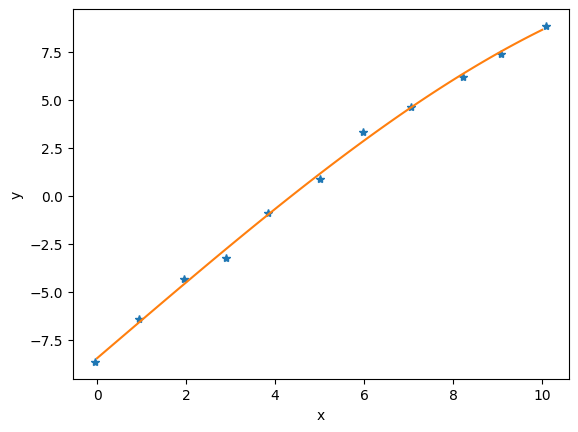

In [6]:
xdata = np.array([
    -0.04,
     0.93,
     1.95,
     2.90,
     3.83,
     5.0,
     5.98,
     7.05,
     8.21,
     9.08,
     10.09
])

ydata = np.array([
    -8.66,
    -6.44,
    -4.36,
    -3.27,
    -0.88,
    0.87,
    3.31,
    4.63,
    6.19,
    7.4,
    8.85
])


m = 3
alpha = polyFit(xdata,ydata,m)
print("Parameter fungsi:\n",alpha)
print("Std. deviasi =", stdDev(alpha,xdata,ydata))

plt.plot(xdata, ydata,'*')
x=np.linspace(0,10,100)
y=np.zeros(100)

# fungsi yang dihitung seperti berikut:
#  y=alpha[0]+alpha[1]*x+alpha[2]*x**2+alpha[3]*x**3

for i in range(len(alpha)):
    y+=alpha[i]*x**i

plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Menggunakan pustaka yang tersedia


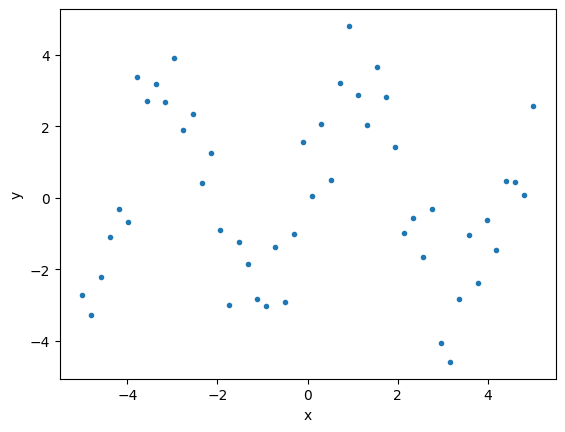

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2937)

x=np.linspace(-5,5,50)
y=2.9*np.sin(1.5*x)+np.random.normal(size=50)

plt.plot(x,y,'.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [8]:
from scipy import optimize

def fitfun(x,a,b):
  return a*np.sin(b*x)

par,cov = optimize.curve_fit(fitfun, x, y, p0=[2,2])

print(par)

[3.03254785 1.47390591]


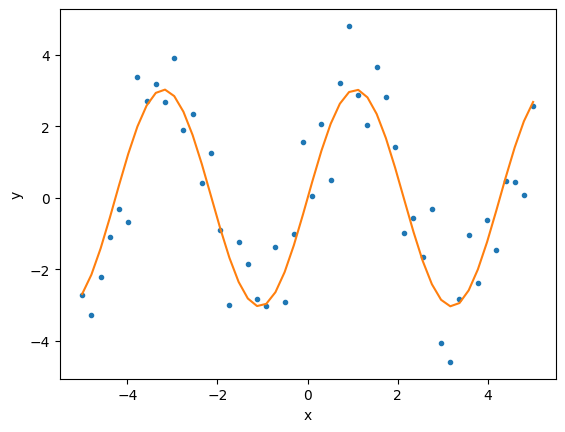

In [13]:
plt.plot(x,y,'.')
plt.plot(x,fitfun(x,par[0],par[1]))
plt.xlabel('x')
plt.ylabel('y')
plt.show()